Device: cuda
Checkpoint: model_checkpoints\decoder_unidirectional_epoch_0012.pt
Checkpoint epoch: 12
Sample: p225_001_mic1.pt
Content shape: (1, 102, 768)
Speaker shape: (1, 192)
Truth mel shape: (102, 80)
Predicted mel shape: (102, 80)
Mean L1: 0.6749
Median abs diff: 0.5743
Max abs diff: 4.1427


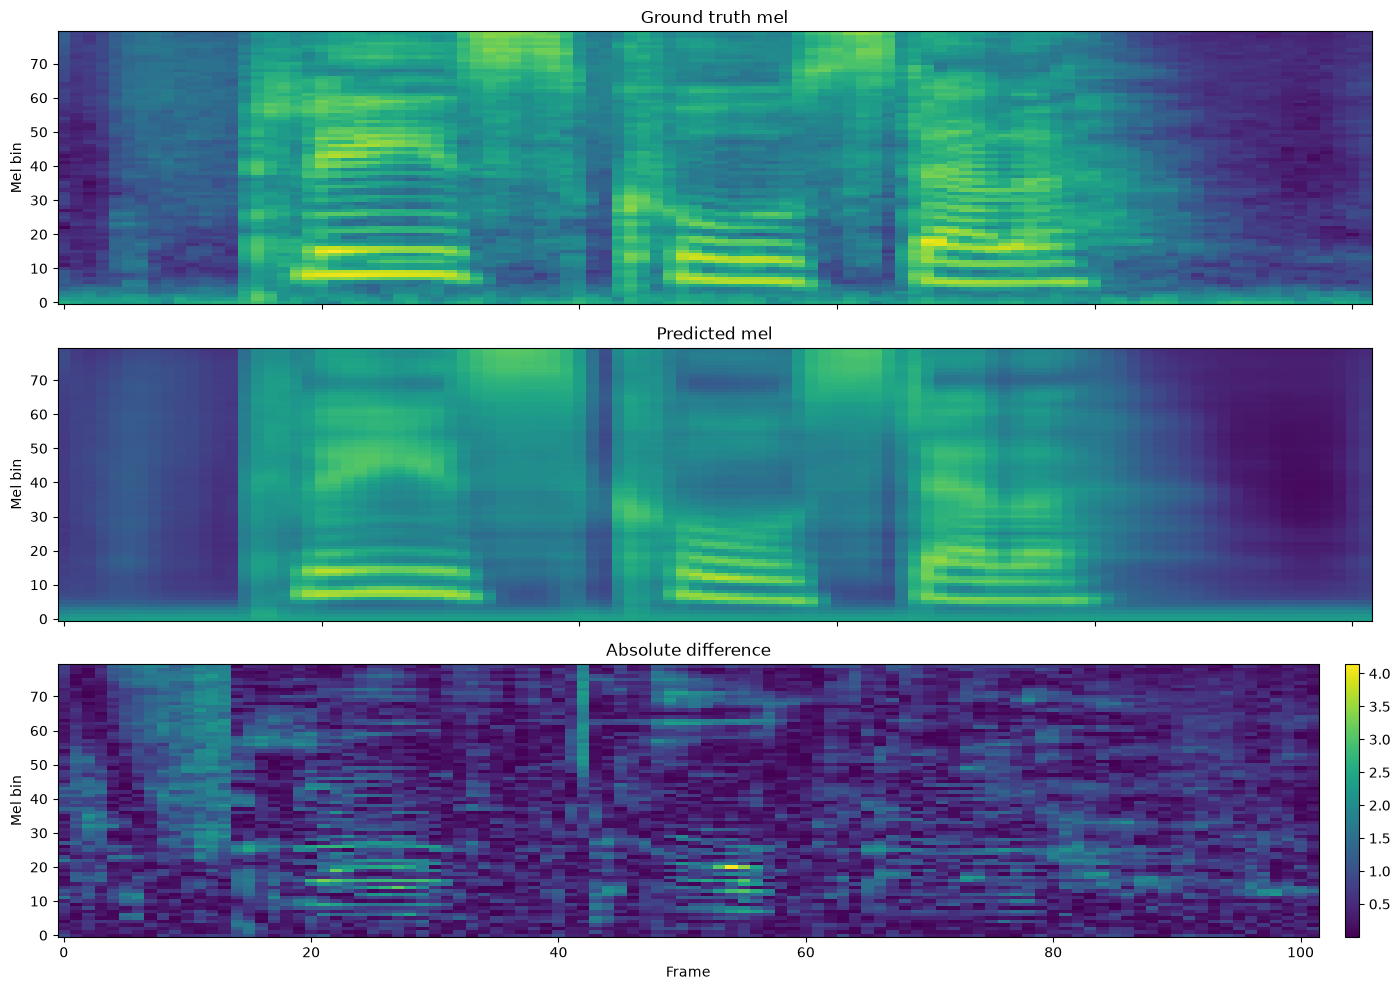

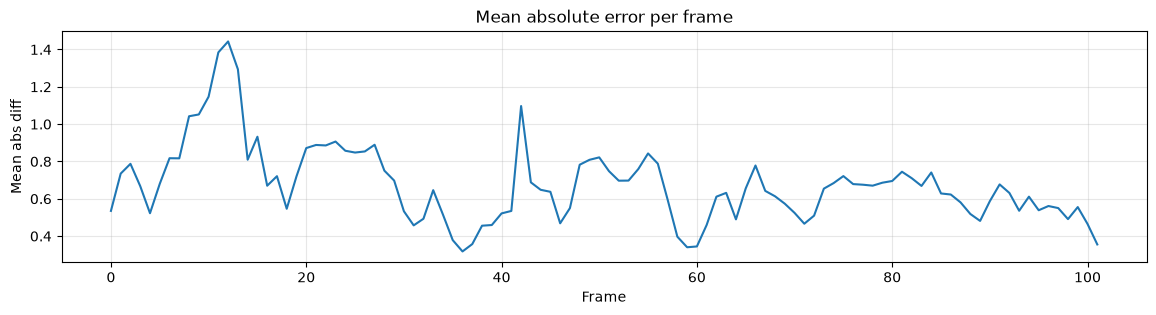

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from decoder import VCDecoder, load_checkpoint
from prepared_datasets.vc_dataset import load_content_latent, squeeze_content, squeeze_mel, squeeze_speaker

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_path = Path("model_checkpoints/decoder_unidirectional_epoch_0012.pt")
sample_id = "p225_001_mic1.pt"
truth_mel_path = Path("datasets/precomputed/mels") / sample_id
content_latent_path = Path("datasets/precomputed/contents") / sample_id
speaker_latent_path = Path("datasets/precomputed/speakers") / sample_id

decoder = VCDecoder().to(device)
checkpoint_info = load_checkpoint(checkpoint_path, decoder, device=device, load_optimizer=False)
decoder.eval()

content_payload = torch.load(content_latent_path, map_location="cpu")
speaker_payload = torch.load(speaker_latent_path, map_location="cpu")
truth_payload = torch.load(truth_mel_path, map_location="cpu")

content = squeeze_content(load_content_latent(content_payload, sample_id)).unsqueeze(0).to(device)
speaker = squeeze_speaker(speaker_payload["speaker_latent"]).unsqueeze(0).to(device)
truth_mel = squeeze_mel(truth_payload["mel"]).to(device)

with torch.no_grad():
    pred_mel = decoder(content, speaker).squeeze(0)

time_steps = min(pred_mel.size(0), truth_mel.size(0))
pred_mel = pred_mel[:time_steps].cpu()
truth_mel = truth_mel[:time_steps].cpu()
abs_diff = (pred_mel - truth_mel).abs()

print(f"Device: {device}")
print(f"Checkpoint: {checkpoint_info['checkpoint_path']}")
print(f"Checkpoint epoch: {checkpoint_info['epoch']}")
print(f"Sample: {sample_id}")
print(f"Content shape: {tuple(content.shape)}")
print(f"Speaker shape: {tuple(speaker.shape)}")
print(f"Truth mel shape: {tuple(truth_mel.shape)}")
print(f"Predicted mel shape: {tuple(pred_mel.shape)}")
print(f"Mean L1: {abs_diff.mean().item():.4f}")
print(f"Median abs diff: {abs_diff.median().item():.4f}")
print(f"Max abs diff: {abs_diff.max().item():.4f}")

vmin = min(truth_mel.min().item(), pred_mel.min().item())
vmax = max(truth_mel.max().item(), pred_mel.max().item())

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].imshow(truth_mel.T, aspect="auto", origin="lower", vmin=vmin, vmax=vmax)
axes[0].set_title("Ground truth mel")
axes[0].set_ylabel("Mel bin")

axes[1].imshow(pred_mel.T, aspect="auto", origin="lower", vmin=vmin, vmax=vmax)
axes[1].set_title("Predicted mel")
axes[1].set_ylabel("Mel bin")

diff_image = axes[2].imshow(abs_diff.T, aspect="auto", origin="lower")
axes[2].set_title("Absolute difference")
axes[2].set_xlabel("Frame")
axes[2].set_ylabel("Mel bin")
fig.colorbar(diff_image, ax=axes[2], fraction=0.02, pad=0.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 3))
plt.plot(abs_diff.mean(dim=1))
plt.title("Mean absolute error per frame")
plt.xlabel("Frame")
plt.ylabel("Mean abs diff")
plt.grid(alpha=0.3)
plt.show()